In [46]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# Previous Bar Charts (from 01 and 03 files...)

## Labor Demand

### Preprocessing

In [24]:
# Base columns (the ones before D1...D11)
base_cols = [
    'Sector', 'Subsector', 'Job_Requirement', 'Tasks',
    'Program', 'Type_of_Program', 'Provincial_Rank'
]

# Repeated patterns per Dx
core_pattern = [
    'Priority', 'Next1-3', 'Next1-5', 'Low', 'Medium',
    'High', 'Final_Score', 'Priority_Ranking'
]
irrelevant_pattern = ['Irrelevant1', 'Irrelevant2', 'Irrelevant3']

# Combine everything up to D11
column_names = base_cols + [
    f'D{i}_{p}' for i in range(1, 12) for p in (core_pattern + irrelevant_pattern)
]

column_names = column_names[:-3]

In [25]:
filepath = 'data/ABDD-Phase1B.xlsx'
df = pd.read_excel(filepath, sheet_name=2, skiprows=7, skipfooter=33, names=column_names)
# Drop columns and rows
df = df.drop(df.filter(regex='Irrelevant').columns, axis=1)

# I am dropping these rows because they dont have a lot of missing data
df = df.drop(df.index[range(470, 481)])


In [26]:
def combine_one_hot(df, prefix, order=["Low", "Medium", "High"], as_numeric=False):
    """
    Combine one-hot encoded columns into a single ordinal column.
    
    Parameters:
        df (pd.DataFrame): DataFrame containing the one-hot columns.
        prefix (str): Prefix of the one-hot columns (e.g. 'D1' for 'D1_Low', 'D1_Medium', 'D1_High').
        order (list): Ordered list of category labels.
        as_numeric (bool): If True, returns numeric ranks (1, 2, 3). Else returns labels.

    Returns:
        pd.Series: Combined ordinal column.
    """
    cols = [f"{prefix}_{label}" for label in order]
    # For each row, find which one-hot column has the value 1, take its column name, and 
    # strip off the prefix (like D1_) to get the category label.
    combined = df[cols].idxmax(axis=1).str.replace(f"{prefix}_", "", regex=False)
    
    if as_numeric:
        mapping = {label: i+1 for i, label in enumerate(order)}
        return combined.map(mapping)
    
    return combined

In [27]:
for i in range(1, 12):
    prefix = f"D{i}"
    new_col = f"{prefix}_level"
    df[new_col] = combine_one_hot(df, prefix)

In [28]:
tourism_df = df[df['Sector'].isin(['CONSTRUCTION', 'MANUFACTURING', 'TOURISM (HOTEL AND RESTAURANT)'])]

In [29]:
levels = [f'D{i}_level' for i in range(1, 12)]
best_mapping = {'High':500, 'Medium':250, 'Low':50}
high_expected_mapping = {'High':450, 'Medium':200, 'Low':40}
low_expected_mapping = {'High':350, 'Medium':150, 'Low':30}
pessimistic_mapping = {'High':250, 'Medium':100, 'Low':10}

best_labor_demand = tourism_df[levels].map(lambda x : best_mapping[x]).sum(axis=0).sum()
high_expected_labor_demand = tourism_df[levels].map(lambda x : high_expected_mapping[x]).sum(axis=0).sum()
low_expected_labor_demand = tourism_df[levels].map(lambda x : low_expected_mapping[x]).sum(axis=0).sum()
pessimistic_labor_demand = tourism_df[levels].map(lambda x : pessimistic_mapping[x]).sum(axis=0).sum()

In [30]:
tourism_df.loc[tourism_df['Program'] == 'FRONT OFFICE SERVICES NC II', levels].map(lambda x : low_expected_mapping[x])

,D1_level,D2_level,D3_level,D4_level,D5_level,D6_level,D7_level,D8_level,D9_level,D10_level,D11_level
321,30,30,30,30,30,30,30,30,30,30,30
324,350,150,150,150,150,150,150,150,150,150,150
326,350,350,30,350,350,350,350,350,350,350,350
329,350,350,30,30,30,30,30,30,30,350,350
332,150,150,150,150,150,150,150,350,150,150,150
333,30,30,30,30,30,30,30,30,30,30,30
335,350,350,350,350,350,350,350,350,350,350,350
340,350,350,350,350,350,350,350,350,350,350,350
345,30,30,30,30,30,30,30,30,30,30,30


In [31]:
num_jobs_demanded = tourism_df[levels].applymap(lambda x: low_expected_mapping[x]).sum(axis=1)

sector_totals = (
    pd.concat([tourism_df['Sector'], num_jobs_demanded], axis=1)
    .groupby('Sector')[0]
    .sum()
    .rename_axis('Sector')
    .reset_index(name='Jobs_Demanded')
)

# Rename TOURISM (HOTEL AND RESTAURANT) → Hospitality
sector_totals['Sector'] = sector_totals['Sector'].replace({
    'CONSTRUCTION': 'Construction',
    'MANUFACTURING': 'Manufacturing',
    'TOURISM (HOTEL AND RESTAURANT)': 'Hospitality'
})

# (Optional) sort in a nice order
sector_totals = sector_totals.sort_values(by='Jobs_Demanded', ascending=False)

print(sector_totals)


          Sector  Jobs_Demanded
0   Construction         123570
1  Manufacturing          83640
2    Hospitality          73970


C:\Users\Raymond\AppData\Local\Temp\ipykernel_22240\1657974452.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  num_jobs_demanded = tourism_df[levels].applymap(lambda x: low_expected_mapping[x]).sum(axis=1)


### Conservative Estimate of Number of Jobs Demanded

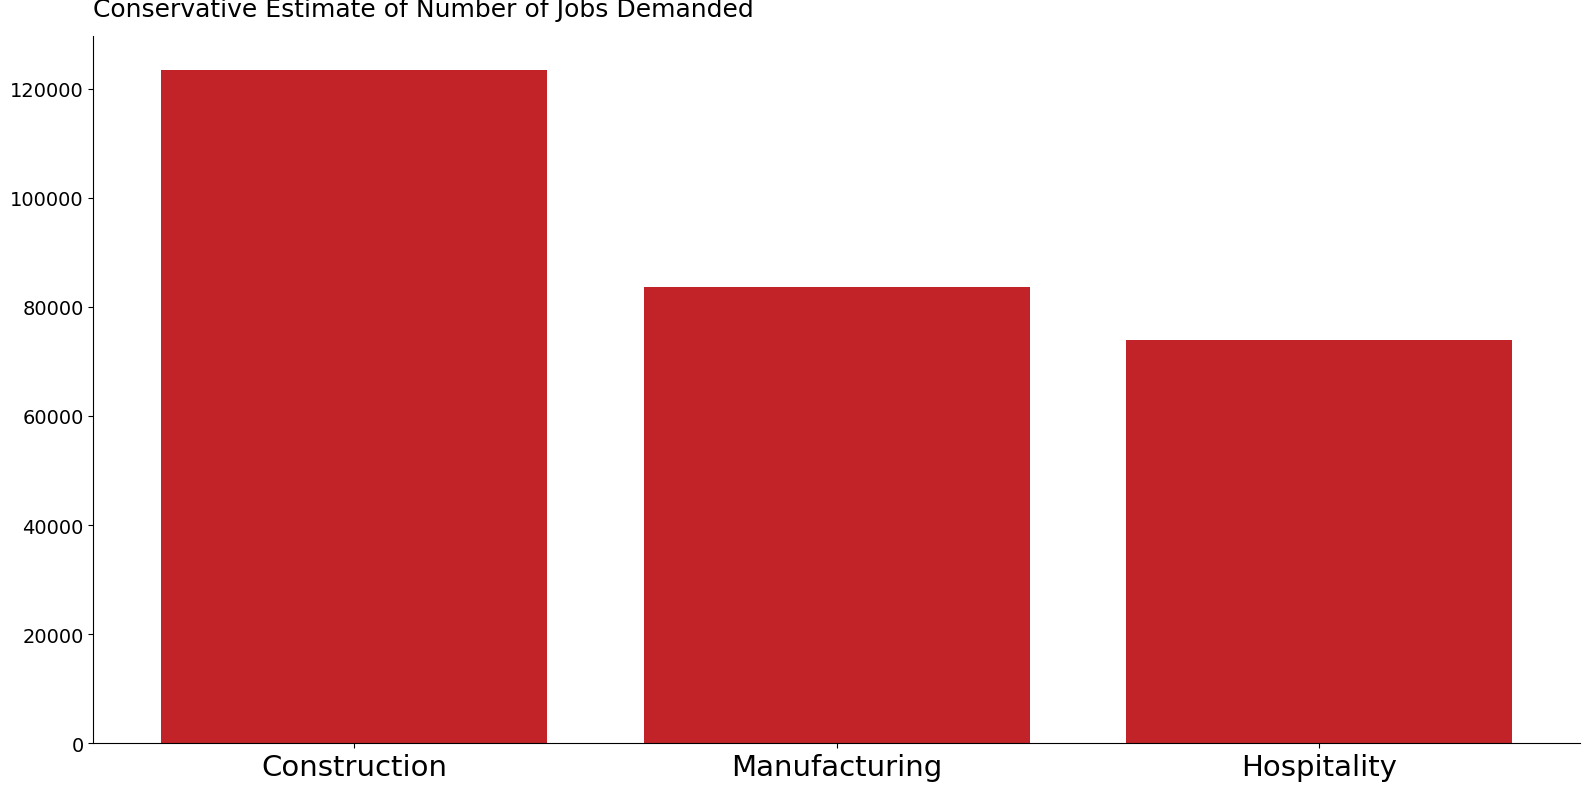

In [32]:
import matplotlib.pyplot as plt

# --- bar chart ---
plt.figure(figsize=(16, 8))
plt.bar(sector_totals['Sector'], sector_totals['Jobs_Demanded'], color='#c12328')

# --- labels and styling ---
plt.ylabel('Conservative Estimate of Number of Jobs Demanded', rotation=0, ha='left', fontsize=18, labelpad=60)
plt.gca().yaxis.set_label_coords(0, 1.02)
plt.xticks(fontsize=21)
plt.yticks(fontsize=14)

# remove top and right borders
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# --- make text fit ---
plt.tight_layout()
plt.show()


## Labor Supply

### Preprocessing

In [34]:
# Load the Excel file
file_path = "data/TESDA 2024 EGAC.xlsx"  # change to your actual path
xls = pd.ExcelFile(file_path)

# Load a specific sheet
df_eg = pd.read_excel(xls, sheet_name='EG 2024')
df_ac = pd.read_excel(xls, sheet_name='AC 2024', header = 1)

In [35]:
unique_quals = df_eg['Qualification'].dropna().unique()
#print(unique_quals)

In [43]:
# Filter rows for Region VII - Central Visayas and tourism/hospitality qualifications
region_vii_cebu_tourism = df_ac[
    (df_ac["Region"] == "Region VII - Central Visayas") &
    (df_ac["Province"] == "Cebu") &
    (df_ac["Qualification"].isin(NC_list))
]

total_certified = region_vii_cebu_tourism["Certified"].sum()

In [38]:
NC_list = [
    # TOURISM
    "Barista NC II",
    "Bartending NC II",
    "Bread and Pastry Production NC II",
    "Cookery NC II",
    "Events Management Services NC III",
    "Food and Beverage Services NC II",
    "Food and Beverage Services NC III",
    "Food and Beverage Services NC IV",
    "Front Office Services NC II",
    "Housekeeping NC II",
    "Housekeeping NC III",
    "Housekeeping NC IV",
    "Local Guiding Services NC II",
    "Tour Guiding Services NC II",
    "Tourism Promotion Services NC II",
    "Tour Packaging (FIT Ad Hoc Domestic) Services NC II",
    "Travel Services NC II",

    # CONSTRUCTION
    "Carpentry NC II",
    "Carpentry NC III",
    "Construction Painting NC II",
    "Electrical Installation and Maintenance NC II",
    "Electrical Installation and Maintenance NC III",
    "Electrical Installation and Maintenance NC IV",
    "Heavy Equipment Operation (Backhoe Loader) NC II",
    "Heavy Equipment Operation (Bulldozer) NC II",
    "Heavy Equipment Operation (Concrete Pump) NC II",
    "Heavy Equipment Operation (Crawler Crane) NC II",
    "Heavy Equipment Operation (Crawler Crane) NC III",
    "Heavy Equipment Operation (Gantry Crane) NC II",
    "Heavy Equipment Operation (Motor Grader) NC II",
    "Heavy Equipment Operation (Overhead and Gantry Crane) NC III",
    "Heavy Equipment Operation (Road Roller) NC II",
    "Heavy Equipment Operation (Rough Terrain Crane) NC II",
    "Heavy Equipment Operation (Rough Terrain Crane) NC III",
    "Heavy Equipment Operation (Tower Crane) NC II",
    "Heavy Equipment Operation (Tower Crane) NC III",
    "Heavy Equipment Operation (Transit Mixer) NC II",
    "Heavy Equipment Operation (Truck Mounted Crane) NC II",
    "Heavy Equipment Operation (Truck Mounted Crane) NC III",
    "Heavy Equipment Operation (Wheel Loader) NC II",
    "Heavy Equipment Servicing (Mechanical) NC II",
    "Masonry NC I",
    "Masonry NC II",
    "Masonry NC III",
    "Plumbing NC I",
    "Plumbing NC II",
    "Plumbing NC III",
    "PV Systems Installation NC II",
    "PV Systems Servicing NC III",
    "Reinforcing Steel Works NC II",
    "Rigging NC I",
    "Scaffolding Works (Supported Type Scaffold) NC II",
    "System Formworks Installation NC II",
    "Tile Setting NC II",

    # MANUFACTURING
    "Automotive Body Repairing NC II",
    "Automotive Painting NC II",
    "CNC Lathe Machine Operation NC II",
    "CNC Milling Machine Operation NC II",
    "Electronic Products Assembly and Servicing NC II",
    "Flux-Cored Arc Welding (FCAW) NC II",
    "Gas Metal Arc Welding (GMAW) NC I",
    "Gas Metal Arc Welding (GMAW) NC II",
    "Gas Metal Arc Welding (GMAW) NC III",
    "Gas Tungsten Arc Welding (GTAW) NC II",
    "Instrumentation and Control Servicing NC II",
    "Instrumentation and Control Servicing NC III",
    "Machining NC I",
    "Machining NC II",
    "Mechatronics Servicing NC II",
    "Mechatronics Servicing NC III",
    "Mechatronics Servicing NC IV",
    "Pipefitting (Metallic) NC II",
    "Shielded Metal Arc Welding (SMAW) NC I",
    "Shielded Metal Arc Welding (SMAW) NC II",
    "Shielded Metal Arc Welding (SMAW) NC III",
    "Shielded Metal Arc Welding (SMAW) NC IV",
    "Technical Drafting NC II"
]


In [40]:
# Filter rows for Region VII - Central Visayas and tourism/hospitality qualifications
region_vii_cebu_tourism = df_ac[
    (df_ac["Region"] == "Region VII - Central Visayas") &
    (df_ac["Province"] == "Cebu") &
    (df_ac["Qualification"].isin(NC_list))
]

total_certified = region_vii_cebu_tourism["Certified"].sum()

print("Total Certified (Tourism & Hospitality, Region VII - Central Visayas):", total_certified)

Total Certified (Tourism & Hospitality, Region VII - Central Visayas): 35318


### Number of Certified Individuals

C:\Users\Raymond\AppData\Local\Temp\ipykernel_22240\2444720945.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  region_vii_cebu_tourism.loc[:, 'Sector'] = region_vii_cebu_tourism['Qualification'].apply(get_sector)


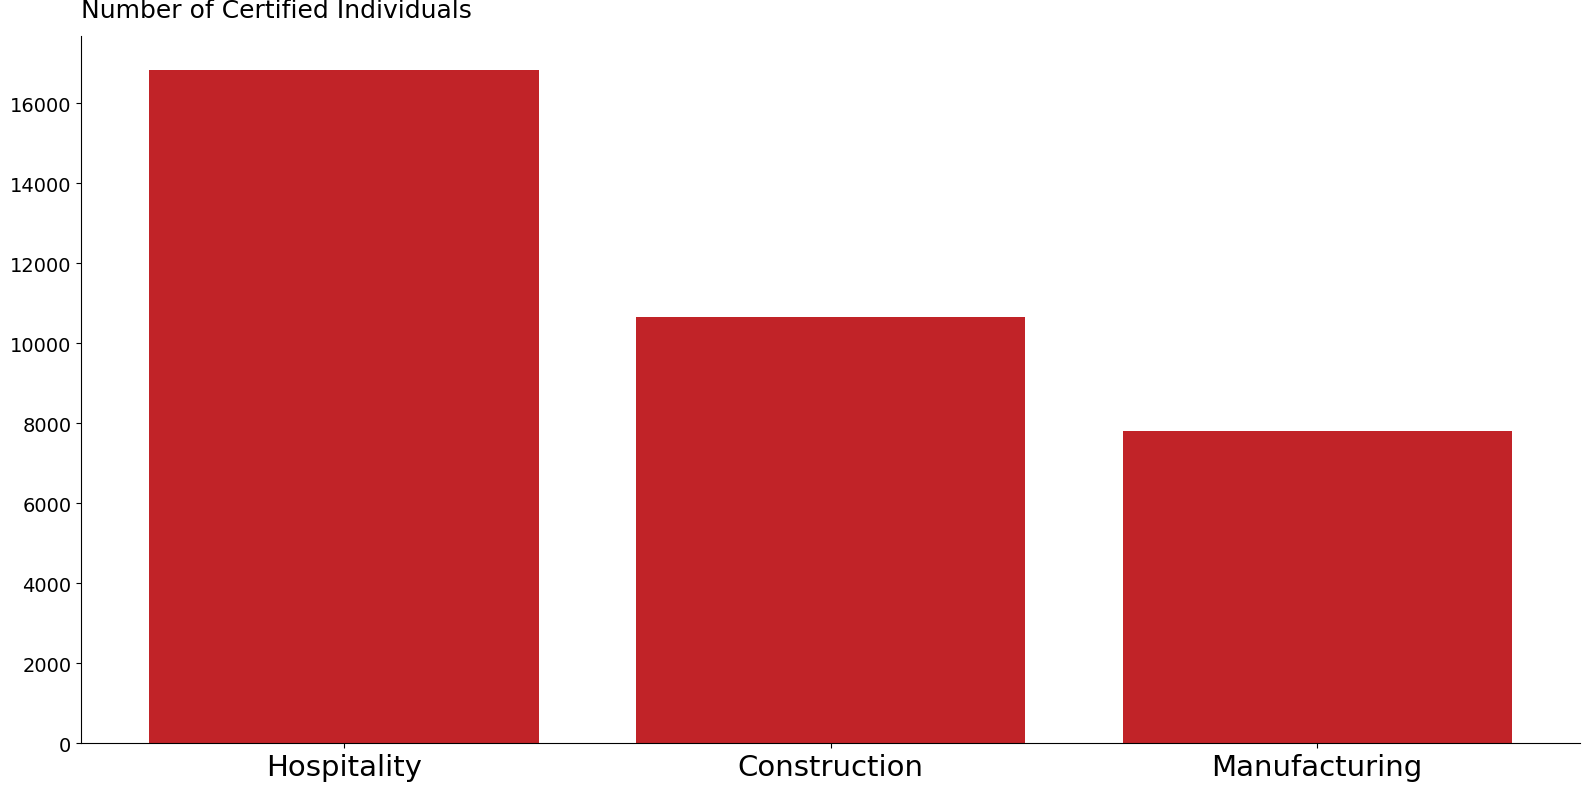

In [41]:
# --- sector mapping ---
tourism_list = NC_list[:17]
construction_list = NC_list[17:17+42]
manufacturing_list = NC_list[17+42:]

def get_sector(qualification):
    if qualification in tourism_list:
        return "Hospitality"
    elif qualification in construction_list:
        return "Construction"
    elif qualification in manufacturing_list:
        return "Manufacturing"
    else:
        return "Other"

# --- apply mapping ---
region_vii_cebu_tourism.loc[:, 'Sector'] = region_vii_cebu_tourism['Qualification'].apply(get_sector)

# --- group and sum ---
sector_summary = (
    region_vii_cebu_tourism.groupby('Sector')['Certified']
    .sum()
    .reset_index()
    .sort_values(by='Certified', ascending=False)   # sort highest → lowest
)

# --- bar chart ---
plt.figure(figsize=(16, 8))
plt.bar(sector_summary['Sector'], sector_summary['Certified'], color='#c12328')

# labels and style
plt.ylabel('Number of Certified Individuals', rotation=0, ha='left', fontsize=18, labelpad=60)
plt.gca().yaxis.set_label_coords(0, 1.02)
plt.xticks(rotation=0, fontsize=21)
plt.yticks(fontsize=14)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()



# Combined Bar Chart

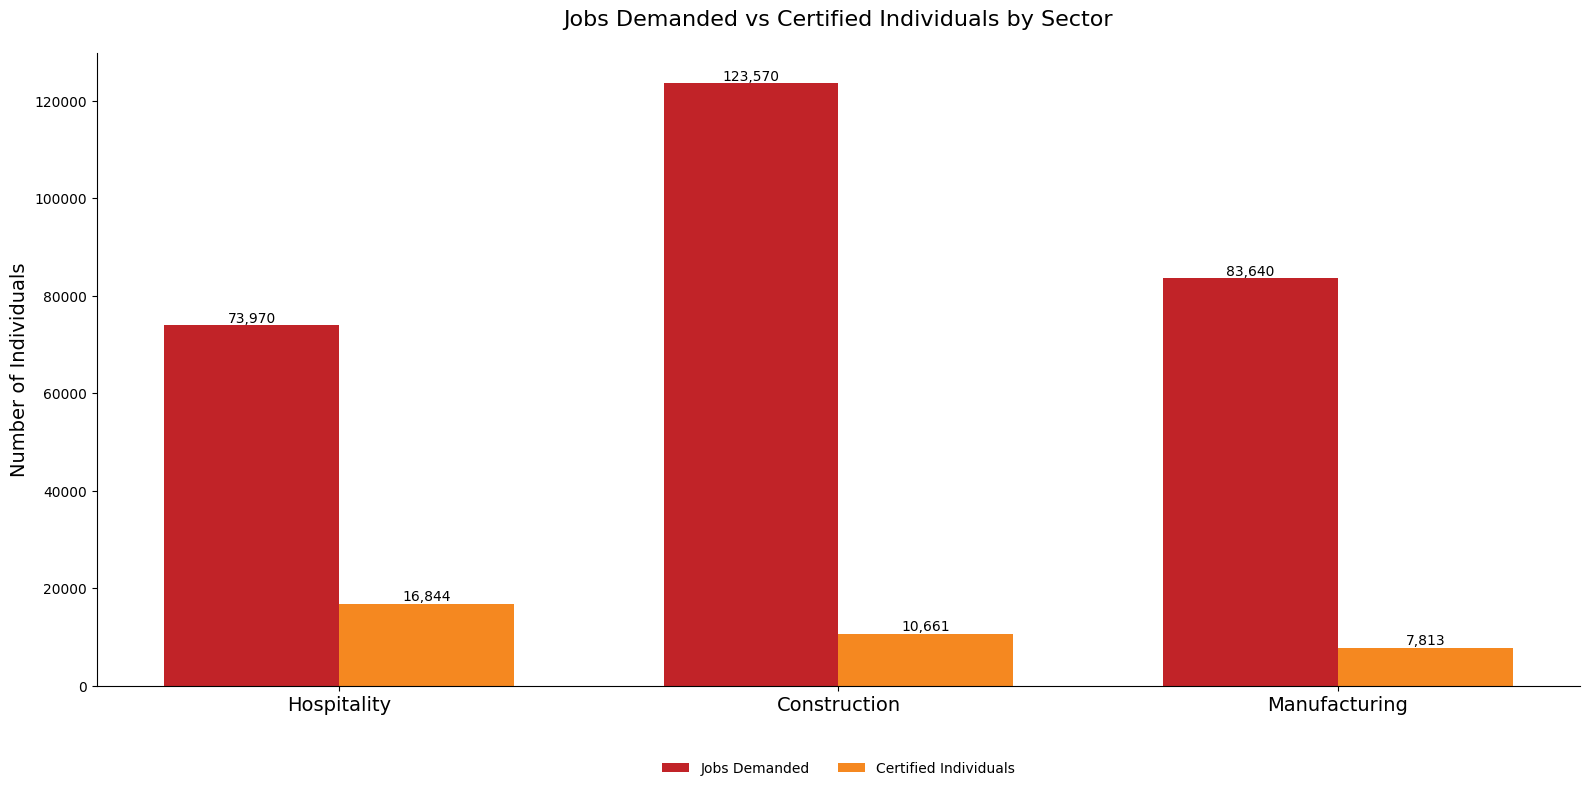


Actual Values (in desired order):
Hospitality: 73,970 jobs demanded, 16,844 certified individuals
  Ratio (Certified/Jobs): 22.77%
Construction: 123,570 jobs demanded, 10,661 certified individuals
  Ratio (Certified/Jobs): 8.63%
Manufacturing: 83,640 jobs demanded, 7,813 certified individuals
  Ratio (Certified/Jobs): 9.34%


In [ ]:
desired_order = ['Hospitality', 'Construction', 'Manufacturing']

# Reorder both datasets to match the desired order
sector_totals_ordered = sector_totals.set_index('Sector').loc[desired_order].reset_index()
sector_summary_ordered = sector_summary.set_index('Sector').loc[desired_order].reset_index()

# Get the sectors in the desired order
sectors = sector_totals_ordered['Sector'].tolist()

# Extract the values for each sector in the desired order
jobs_demanded = sector_totals_ordered['Jobs_Demanded'].tolist()
certified_individuals = sector_summary_ordered['Certified'].tolist()

fig, ax = plt.subplots(figsize=(16, 8))

# Set the width of bars and positions
bar_width = 0.35
x_pos = np.arange(len(sectors))

# Create bars for both datasets on the same y-axis
bars1 = ax.bar(x_pos - bar_width/2, jobs_demanded, bar_width, 
                color='#c12328', label='Jobs Demanded')
bars2 = ax.bar(x_pos + bar_width/2, certified_individuals, bar_width, 
                color='#f58820ff', label='Certified Individuals')

# Setting labels
ax.set_ylabel('Number of Individuals', fontsize=14)
ax.set_xticks(x_pos)
ax.set_xticklabels(sectors, fontsize=14)

# legend
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=2,
    frameon=False
)

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add value labels on bars
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:,.0f}', ha='center', va='bottom', fontsize=10)
add_value_labels(bars1)
add_value_labels(bars2)

# Adjust layout
plt.title('Jobs Demanded vs Certified Individuals by Sector', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Show the actual values for reference
print("\nActual Values (in desired order):")
for i, sector in enumerate(sectors):
    print(f"{sector}: {jobs_demanded[i]:,} jobs demanded, {certified_individuals[i]:,} certified individuals")
    print(f"  Ratio (Certified/Jobs): {certified_individuals[i]/jobs_demanded[i]:.2%}")